handling repeated measures of the same subject (different sessions) better (before = removed duplicates by subject_id, now by subjecgt_id+session_id)

harmonization recieves combined_gm_volues (long format of of the data - metadata+volumes in each roi)
returns the same df but with an extra colmn - 'harmonized_volume_mm3' that is the harmonized volumes 

Scans per Super-Batch:
super_batch
Tel-Aviv University_SIEMENS                  4074
ICHILOV TEL AVIV_GE MEDICAL SYSTEMS           540
SHEBA_ MEDICAL_ CENTER_GE MEDICAL SYSTEMS     166
Name: count, dtype: int64
Variable: birth_year | ANOVA p-value: 0.0000
🚨 ALERT: Strong confounding in birth_year
Variable: age_in_years | ANOVA p-value: 0.0000
🚨 ALERT: Strong confounding in age_in_years
Variable: tiv | ANOVA p-value: 0.0001
🚨 ALERT: Strong confounding in tiv
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


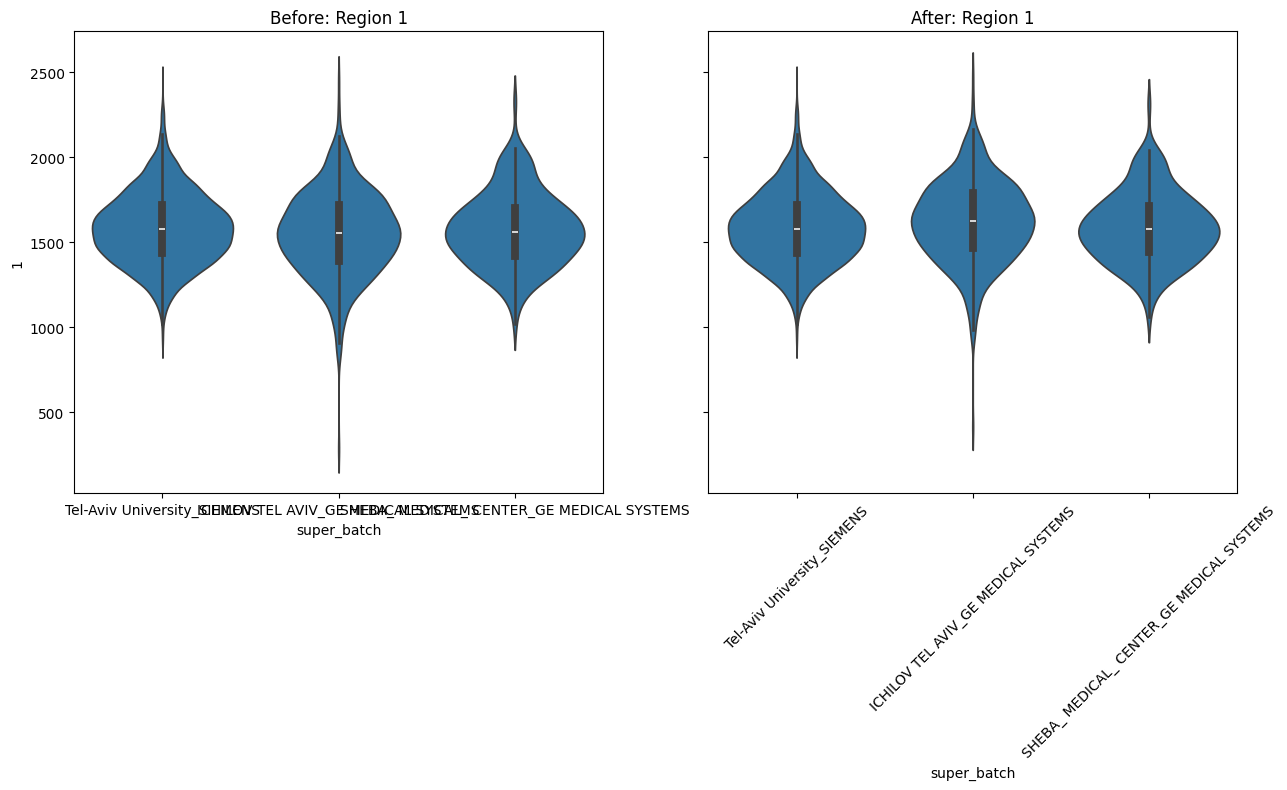

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency, gaussian_kde
from scipy.integrate import simpson
from itertools import combinations
from neuroCombat import neuroCombat

df = pd.read_pickle('/home/gaia/Projects/legacy_data/best_combined_gm_volumes.pkl')

df = df[df['birth_year'] > 1910]

# --- 1. SETTINGS & PREPARATION ---
# Create unique Scan ID for longitudinal tracking
df['scan_id'] = df['subject_id'].astype(str) + "_" + df['session_id'].astype(str)

tested_batch = 'super_batch'
dependent_vars = ['birth_year', 'age_in_years', 'sex_c', 'tiv']

# Create the Super-Batch ID
df['super_batch'] = df['institute'].astype(str) + "_" + df['manufacturer'].astype(str)
df['sex_c'] = df['sex'].map({'M': 0, 'F': 1})

# --- 2. DATA PIVOTING & ALIGNMENT ---
# Rows = Scans, Columns = Regions
df_features = df.pivot_table(
    index='scan_id', 
    columns='region_label', 
    values='volume_mm3', 
    aggfunc='mean'
).sort_index()

# Get matching metadata for these exact scans
df_covariates = df.drop_duplicates(subset=['scan_id']).set_index('scan_id').sort_index()
df_covariates = df_covariates.loc[df_features.index] # Force identical order

# Clean missing values
df_features = df_features.dropna()
df_covariates = df_covariates.loc[df_features.index]

# Print how many scans are per batch
print("Scans per Super-Batch:")
print(df_covariates['super_batch'].value_counts())

# --- 3. CONFOUNTING & OVERLAP CHECKS ---
def check_confounding(df, var_name):
    groups = [group[var_name].values for _, group in df.groupby('super_batch')]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"Variable: {var_name} | ANOVA p-value: {p_val:.4f}")
    if p_val < 0.05: print(f"🚨 ALERT: Strong confounding in {var_name}")

for var in ['birth_year', 'age_in_years', 'tiv']:
    check_confounding(df_covariates, var)

# --- 4. NEUROCOMBAT EXECUTION ---
# IMPORTANT: NeuroComBat expects (features x samples)
data_to_harmonize = df_features.transpose().to_numpy()

# Fix NumPy alias bug
np.int = int 

# Define Model Parameters
categorical_cols = ['sex_c']
continuous_cols = ['age_in_years', 'birth_year', 'tiv']

result = neuroCombat(
    dat=data_to_harmonize,
    covars=df_covariates,
    batch_col='super_batch',
    categorical_cols=categorical_cols,
    continuous_cols=continuous_cols,
    ref_batch="Tel-Aviv University_SIEMENS"
)

# NeuroComBat returns a dictionary; 'data' is the corrected matrix
harmonized_data = result['data']

# Convert back to Subject-Row format
df_harmonized = pd.DataFrame(
    harmonized_data.transpose(), 
    index=df_features.index, 
    columns=df_features.columns
)


# --- 5. VISUALIZATION ---
def plot_comparison(region_id):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    sns.violinplot(data=df_features, x=df_covariates['super_batch'], y=region_id, ax=axes[0])
    axes[0].set_title(f"Before: Region {region_id}")
    sns.violinplot(data=df_harmonized, x=df_covariates['super_batch'], y=region_id, ax=axes[1])
    axes[1].set_title(f"After: Region {region_id}")
    plt.xticks(rotation=45)
    plt.show()

plot_comparison(df_features.columns[0])

# --- 6. EXPORTING BACK TO LONG FORMAT ---
df_harmonized_long = df_harmonized.reset_index().melt(
    id_vars='scan_id', 
    var_name='region_label', 
    value_name='volume_mm3_harmonized'
)

df_final = df.merge(df_harmonized_long, on=['scan_id', 'region_label'], how='left')



--- Confounding Check (Batch vs. Birth Year) ---


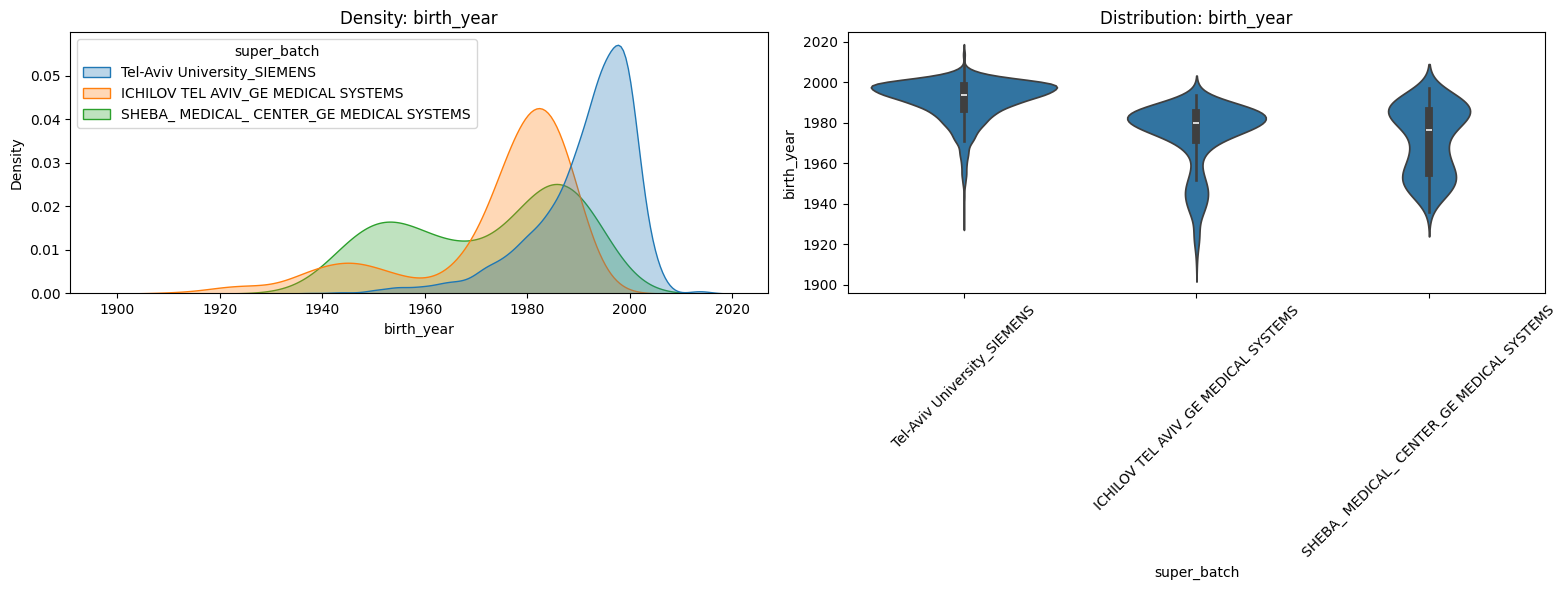

ANOVA F-statistic: 754.8569
ANOVA p-value: 0.0000
ALERT: Strong confounding detected. birth_year differs significantly across batches.
NeuroCombat will need to work harder to separate biological variance from site effects.

--- Confounding Check (Batch vs. Age In Years) ---


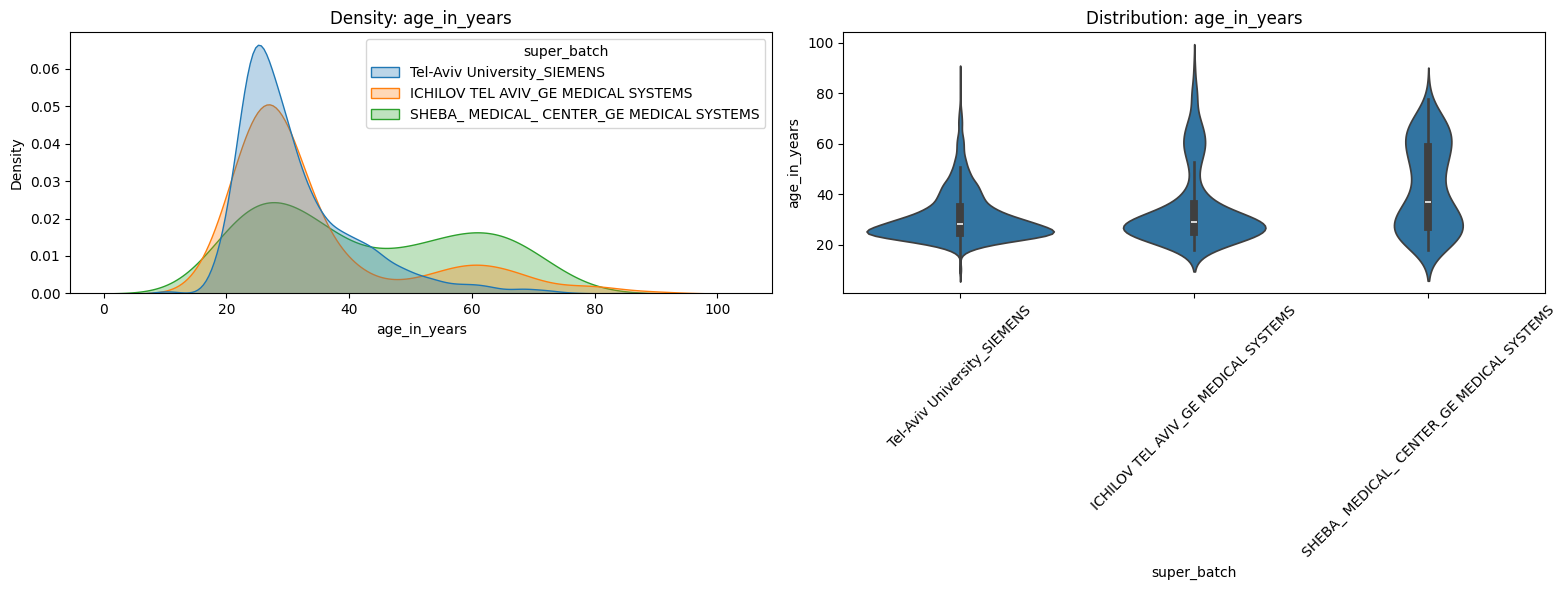

ANOVA F-statistic: 98.4820
ANOVA p-value: 0.0000
ALERT: Strong confounding detected. age_in_years differs significantly across batches.
NeuroCombat will need to work harder to separate biological variance from site effects.

--- Confounding Check (Batch vs. Sex C) ---


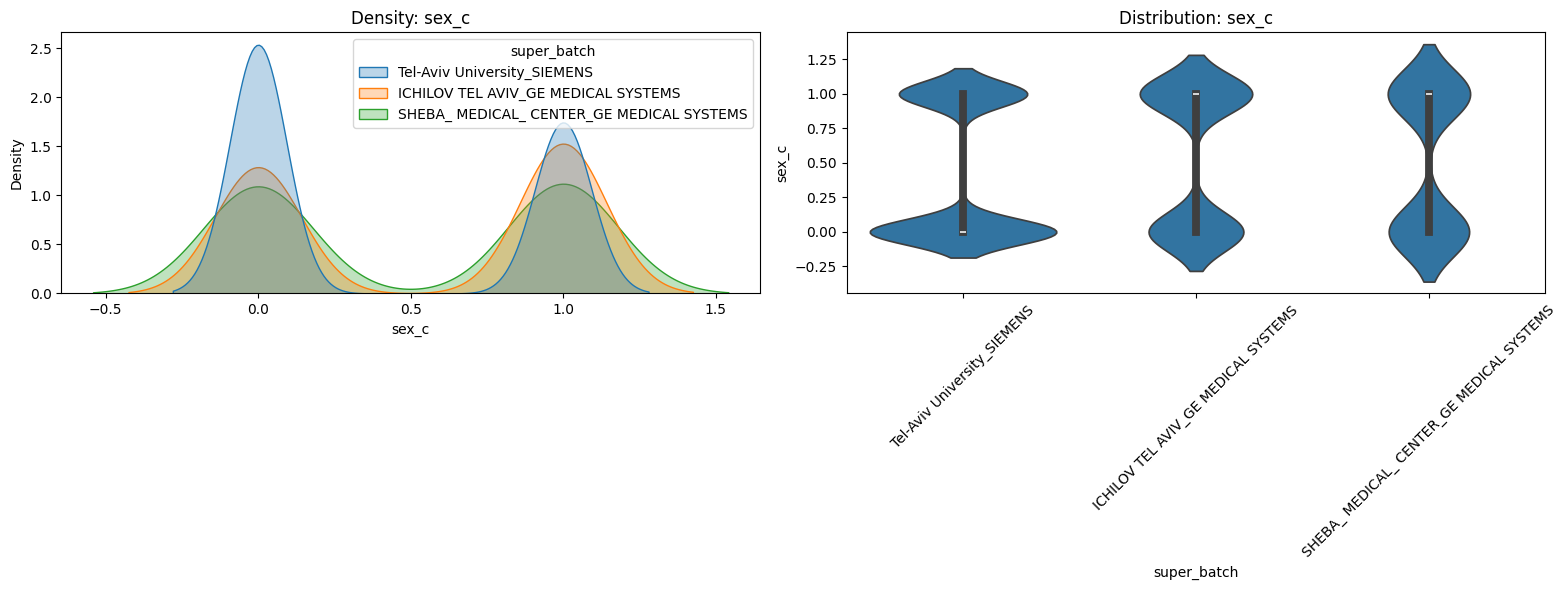

ANOVA F-statistic: 20.2015
ANOVA p-value: 0.0000
ALERT: Strong confounding detected. sex_c differs significantly across batches.
NeuroCombat will need to work harder to separate biological variance from site effects.

--- Confounding Check (Batch vs. Tiv) ---


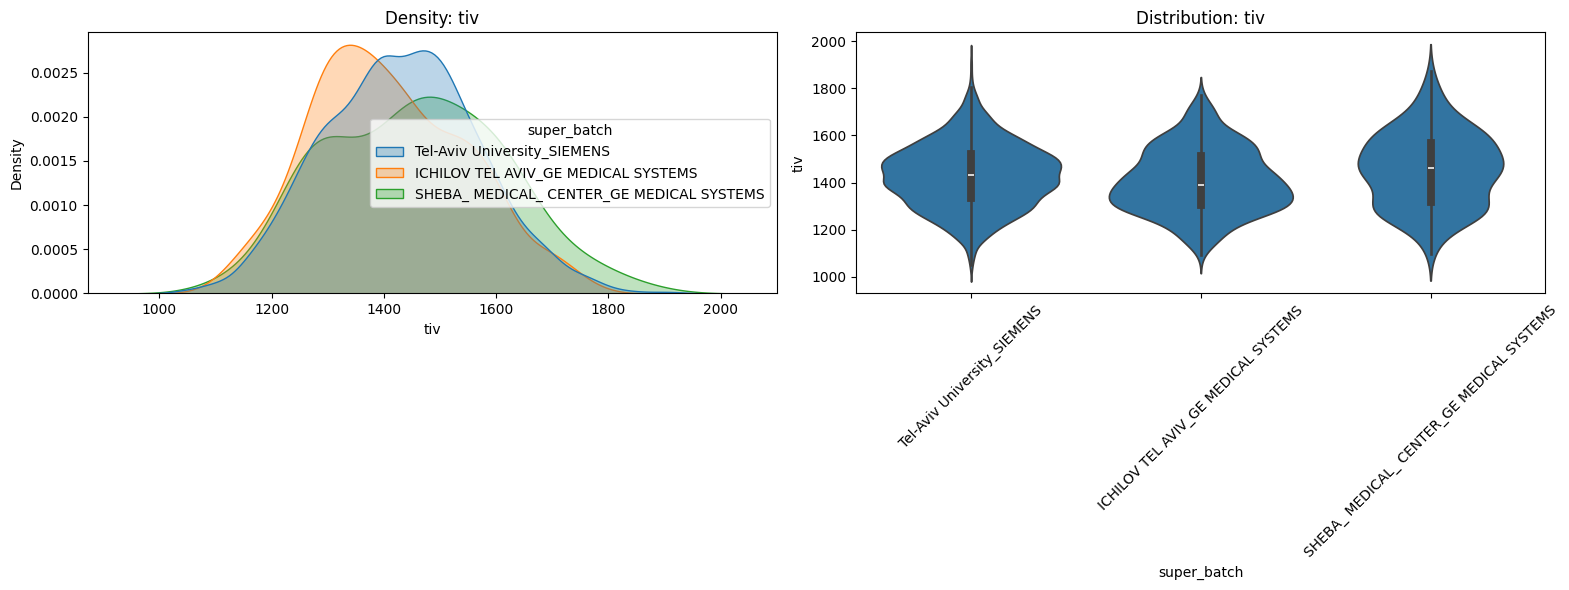

ANOVA F-statistic: 9.7188
ANOVA p-value: 0.0001
ALERT: Strong confounding detected. tiv differs significantly across batches.
NeuroCombat will need to work harder to separate biological variance from site effects.


In [2]:
def check_confounding(df, var_name):
    print(f"\n--- Confounding Check (Batch vs. {var_name.replace('_', ' ').title()}) ---")

    batch_col = 'super_batch'

    # 2. Create Plotting Grid (Two plots side-by-side for efficiency)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # KDE Plot
    sns.kdeplot(data=df, x=var_name, hue=batch_col, 
                fill=True, alpha=0.3, ax=axes[0], common_norm=False)
    axes[0].set_title(f"Density: {var_name}")
    
    # Violin Plot
    sns.violinplot(data=df, x=batch_col, y=var_name, ax=axes[1])
    axes[1].set_title(f"Distribution: {var_name}")
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

    # 3. Statistical Test (ANOVA)
    # Grouping data into a list of arrays for f_oneway
    groups = [group[var_name].values for _, group in df.groupby(batch_col)]
    
    f_stat, p_val = stats.f_oneway(*groups)

    print(f"ANOVA F-statistic: {f_stat:.4f}")
    print(f"ANOVA p-value: {p_val:.4f}")

    if p_val < 0.05:
        print(f"ALERT: Strong confounding detected. {var_name} differs significantly across batches.")
        print("NeuroCombat will need to work harder to separate biological variance from site effects.")
    else:
        print(f"PASS: No significant difference in {var_name} across batches.")

# 4. Iterate over your list
for var in dependent_vars:
    check_confounding(df_covariates, var)

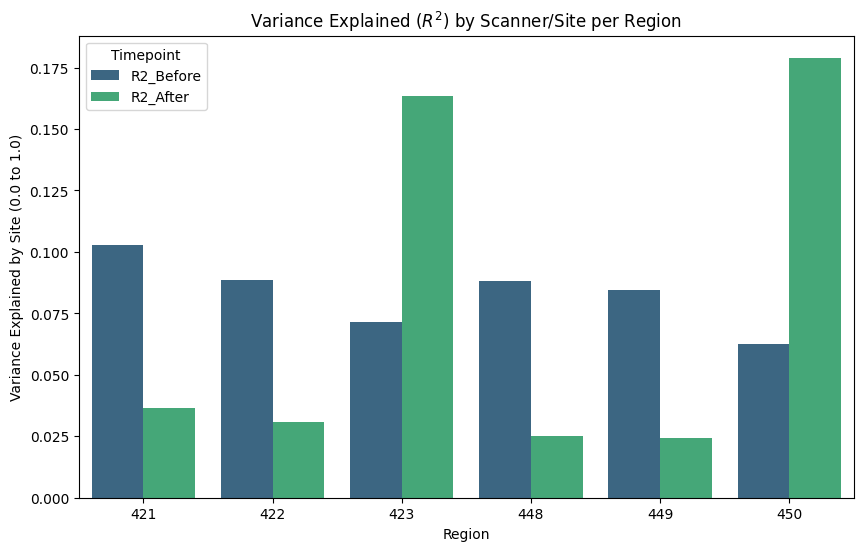

Average Variance Explained by Site BEFORE: 0.0830
Average Variance Explained by Site AFTER: 0.0766


In [3]:
from statsmodels.formula.api import ols

def calculate_site_variance(features_df, covariates_df, region):
    """Calculates R-squared (variance explained) by the batch effect."""
    # Combine data for a single region
    temp_df = pd.concat([features_df[region], covariates_df['super_batch']], axis=1)
    temp_df.columns = ['volume', 'batch']
    
    # Fit a simple linear model: Volume ~ Batch
    model = ols('volume ~ C(batch)', data=temp_df).fit()
    return model.rsquared

df_covariates['super_batch'] = df_covariates['super_batch'].astype('category')

# Select a subset of regions to test (e.g., first 10)
test_regions = [421, 422, 423, 448, 449, 450]

metrics = []
for reg in test_regions:
    r2_before = calculate_site_variance(df_features, df_covariates, reg)
    r2_after = calculate_site_variance(df_harmonized, df_covariates, reg)
    metrics.append({'Region': reg, 'R2_Before': r2_before, 'R2_After': r2_after})

df_metrics = pd.DataFrame(metrics)

# --- Visualize the Reduction in Site Effect ---
plt.figure(figsize=(10, 6))
df_plot = df_metrics.melt(id_vars='Region', var_name='Timepoint', value_name='R_squared')
sns.barplot(data=df_plot, x='Region', y='R_squared', hue='Timepoint', palette='viridis')
plt.title("Variance Explained ($R^2$) by Scanner/Site per Region")
plt.ylabel("Variance Explained by Site (0.0 to 1.0)")
plt.show()

print(f"Average Variance Explained by Site BEFORE: {df_metrics['R2_Before'].mean():.4f}")
print(f"Average Variance Explained by Site AFTER: {df_metrics['R2_After'].mean():.4f}")

In [4]:
# Run this to see the overlap
print(df_covariates.groupby('super_batch')['birth_year'].agg(['min', 'max', 'mean']))

                                            min   max         mean
super_batch                                                       
ICHILOV TEL AVIV_GE MEDICAL SYSTEMS        1911  1994  1973.831481
SHEBA_ MEDICAL_ CENTER_GE MEDICAL SYSTEMS  1936  1997  1971.728916
Tel-Aviv University_SIEMENS                1931  2015  1991.224595


In [5]:
# increase in R^2 is a red flag - overcorretion or data misalignment.
# make sure data is aligned

import pandas as pd

def check_alignment(df1, df2, name1="df_harmonized", name2="df_covariates"):
    print(f"--- Alignment Check: {name1} vs {name2} ---")
    
    # 1. Check Dimensions
    shape_match = df1.shape[0] == df2.shape[0]
    print(f"Row Count Match: {shape_match} ({df1.shape[0]} vs {df2.shape[0]})")
    
    # 2. Check Index Content
    # Checks if both have the same Subject IDs, regardless of order
    diff = set(df1.index) ^ set(df2.index)
    if not diff:
        print("Index Content: Match (Both dataframes contain the same Subject IDs)")
    else:
        print(f"Index Content: MISMATCH! IDs unique to one DF: {list(diff)[:5]}...")

    # 3. Check Exact Order (Crucial for OLS/Statsmodels)
    order_match = all(df1.index == df2.index)
    print(f"Exact Order Match: {order_match}")
    
    if not order_match and not diff:
        print("⚠️ WARNING: The DataFrames contain the same IDs but they are SHUFFLED.")
        print("   Run: df_harmonized = df_harmonized.loc[df_covariates.index]")
    elif not order_match:
        print("❌ ERROR: DataFrames are significantly misaligned.")

# Run the check
check_alignment(df_harmonized, df_covariates)

# --- QUICK FIX IF MISALIGNED ---
# If the indexes contain the same IDs but are just out of order:
# df_harmonized = df_harmonized.loc[df_covariates.index]

--- Alignment Check: df_harmonized vs df_covariates ---
Row Count Match: True (4780 vs 4780)
Index Content: Match (Both dataframes contain the same Subject IDs)
Exact Order Match: True


Processing 454 regions...
Running NeuroComBat on residuals...
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


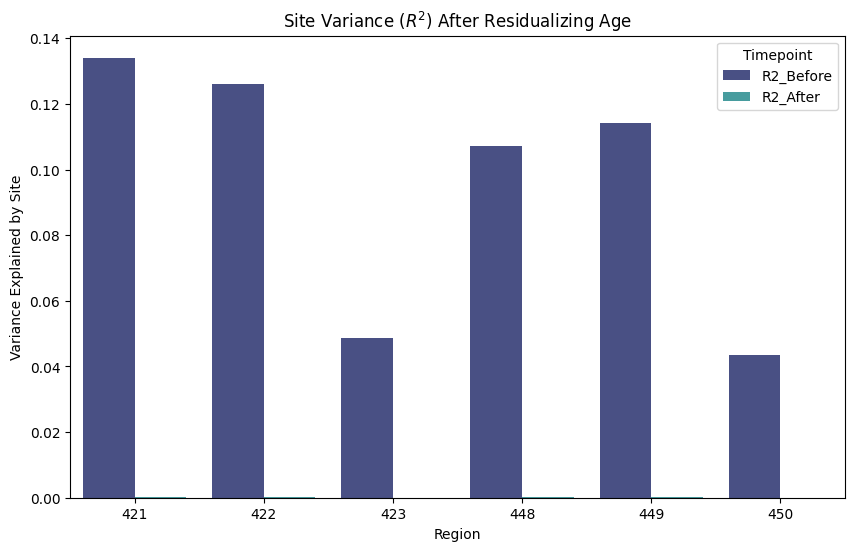

Average Variance Explained by Site BEFORE: 0.0956
Average Variance Explained by Site AFTER: 0.0001


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
from neuroCombat import neuroCombat

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS

def get_residuals(data_df, covars_df):
    """Regresses out age, sex, and tiv to create clean residuals with type checking."""
    # 1. Ensure all inputs are numeric and drop any rows with NaNs in predictors
    X_cols = ['age_in_years', 'sex_c', 'tiv']
    
    # Force numeric conversion for predictors
    X = covars_df[X_cols].apply(pd.to_numeric, errors='coerce')
    X = sm.add_constant(X)
    
    # Initialize the output dataframe
    residuals_df = pd.DataFrame(index=data_df.index, columns=data_df.columns)
    
    print(f"Processing {len(data_df.columns)} regions...")
    
    for region in data_df.columns:
        # Force numeric conversion for the brain data (the dependent variable)
        y = pd.to_numeric(data_df[region], errors='coerce')
        
        # Combined mask to drop NaNs for this specific region + predictors
        mask = y.notnull() & X.notnull().all(axis=1)
        
        if mask.sum() < 10: # Safety check
            print(f"Warning: Region {region} has insufficient data. Skipping.")
            continue
            
        # Fit model on valid, numeric data only
        model = OLS(y[mask], X[mask]).fit()
        
        # Place residuals back into the aligned index
        residuals_df.loc[mask, region] = model.resid

    # Final cast to ensure the whole DF is float64, not 'object'
    return residuals_df.astype(float)

# Execute the fix
df_features_res = get_residuals(df_features, df_covariates)

# --- STEP 2: HARMONIZATION ON RESIDUALS ---
# NeuroCombat on residuals protects the Birth Year signal 
# because Age variance is already removed.
np.int = int  # Fix for NumPy version mismatch

data_res = df_features_res.transpose().to_numpy()

print("Running NeuroComBat on residuals...")
result = neuroCombat(
    dat=data_res,
    covars=df_covariates,
    batch_col='super_batch',
    continuous_cols=['birth_year'], # Only protect Birth Year now
    ref_batch="Tel-Aviv University_SIEMENS"
)

df_harmonized_res = pd.DataFrame(
    result['data'].transpose(), 
    index=df_features.index, 
    columns=df_features.columns
)


def calculate_r2(features_df, covars_df, region):
    temp_df = pd.concat([features_df[region], covars_df['super_batch']], axis=1)
    temp_df.columns = ['val', 'batch']
    # Variance explained by Site
    return OLS.from_formula('val ~ C(batch)', data=temp_df).fit().rsquared

# Compare Site Variance for specific regions of interest
target_regions = [421, 422, 423, 448, 449, 450]
comparison = []

for reg in target_regions:
    r2_pre = calculate_r2(df_features_res, df_covariates, reg)
    r2_post = calculate_r2(df_harmonized_res, df_covariates, reg)
    comparison.append({'Region': reg, 'R2_Before': r2_pre, 'R2_After': r2_post})

df_comp = pd.DataFrame(comparison)

# --- PLOT 1: Site Variance Reduction ---
plt.figure(figsize=(10, 6))
df_plot = df_comp.melt(id_vars='Region', var_name='Timepoint', value_name='R2')
sns.barplot(data=df_plot, x='Region', y='R2', hue='Timepoint', palette='mako')
plt.title("Site Variance ($R^2$) After Residualizing Age")
plt.ylabel("Variance Explained by Site")
plt.show()


print(f"Average Variance Explained by Site BEFORE: {df_comp['R2_Before'].mean():.4f}")
print(f"Average Variance Explained by Site AFTER: {df_comp['R2_After'].mean():.4f}")

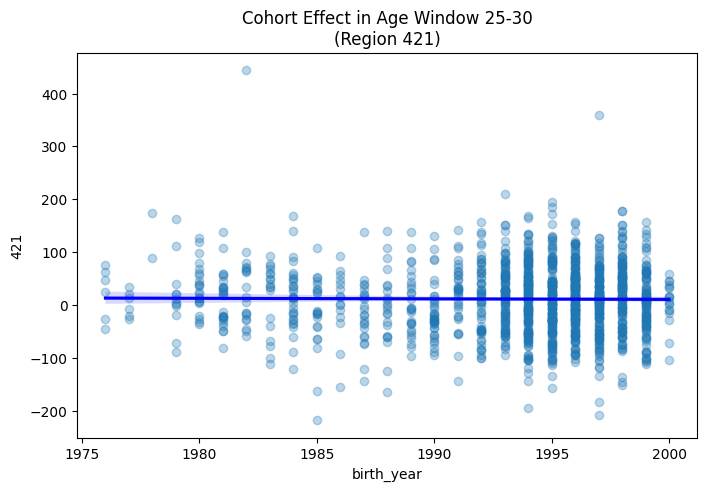

In [13]:
# Select a window where you have good site overlap (e.g., Age 25)
age_window = 25
subset_mask = (df_covariates['age_in_years'] >= age_window) & (df_covariates['age_in_years'] < age_window + 5)

reg_to_check = 421


plt.figure(figsize=(8, 5))
sns.regplot(
    x=df_covariates.loc[subset_mask, 'birth_year'], 
    y=df_harmonized_res.loc[subset_mask, reg_to_check], 
    scatter_kws={'alpha':0.3}, line_kws={'color':'blue'}
)
plt.title(f"Cohort Effect in Age Window {age_window}-{age_window+5}\n(Region {reg_to_check})")
plt.show()

In [14]:
# save to pickle
df_final.to_pickle('/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/best_harmonized_combined_gm_volumes.pkl')